In [860]:
import torch
from torch.utils.data import Dataset
from PIL import Image
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from torchvision.datasets import MNIST, CIFAR10, CIFAR100, STL10
from tqdm.auto import tqdm
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import shapiro, normaltest
import importlib
import pandas as pd
import skimage.io as io
from math import log, sqrt

In [861]:
def shift_and_rms(x, eps=1e-12):
    shift = x.mean(dim=0, keepdim=True)
    x_shifted = x - shift

    rms = x_shifted.norm(dim=1).square().mean().sqrt()
    rms = rms.clamp_min(eps)

    x_norm = x_shifted / rms

    return shift, rms, x_norm

In [862]:
if torch.cuda.is_available():
    device = torch.device('cuda')
    torch.cuda.empty_cache()
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

### Load data

In [ ]:

class PokemonDataset(Dataset):
    def __init__(
        self,
        root = "",
        variant="normal",
        game="red-blue",
        image_col="local_path",   # "local_path" = color, "bw_path" = black/white
        size=32,
        one_per_pokemon=True,
        mode="rgb",               # "rgb", "rgba", or "mask"
    ):
        self.root = root
        info = pd.read_csv(self.root + "pokemondb_sprites/metadata.csv")

        sub_info = info[
            (info["game"] == game)
            & (info["variant"] == variant)
        ].copy()

        sub_info = sub_info[
            sub_info[image_col].notna()
            & (sub_info[image_col].astype(str) != "")
        ]

        if one_per_pokemon:
            sub_info = sub_info.groupby("pokemon", as_index=False).first()

        self.paths = sub_info[image_col].astype(str).tolist()
        self.names = sub_info["pokemon"].astype(str).tolist()

        self.classes = sorted(set(self.names))
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}
        self.labels = [self.class_to_idx[n] for n in self.names]

        self.size = size
        self.mode = mode

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.root + self.paths[idx]
        label = torch.tensor(self.labels[idx], dtype=torch.long)

        img = Image.open(path).convert("RGBA")

        if self.size is not None:
            img = img.resize((self.size, self.size), Image.Resampling.NEAREST)

        arr = np.asarray(img).astype(np.float32) / 255.0

        if self.mode == "mask":
            # Binary alpha mask: [1, H, W]
            alpha = arr[..., 3]
            x = torch.from_numpy((alpha > 0).astype(np.float32)).unsqueeze(0)

        elif self.mode == "rgba":
            # Keep transparency: [4, H, W]
            x = torch.from_numpy(arr).permute(2, 0, 1)

        elif self.mode == "rgb":
            # Composite transparent background onto white: [3, H, W]
            rgb = arr[..., :3]
            alpha = arr[..., 3:4]
            bg = np.ones_like(rgb)
            rgb = alpha * rgb + (1.0 - alpha) * bg
            x = torch.from_numpy(rgb).permute(2, 0, 1)

        else:
            raise ValueError(f"Unknown mode: {self.mode}")

        return x, label

In [ ]:
torch.manual_seed(1101252)
IMG_SIZE = 32
DATASET = "cifar100"  # "cifar100", "stl10", "mnist", or "pokemon"

tfm = T.Compose([
    T.Resize(IMG_SIZE, interpolation=T.InterpolationMode.BICUBIC),
    T.CenterCrop(IMG_SIZE),
    T.ToTensor(),
])

if DATASET == "cifar100":
    dataset = CIFAR100(root="datasets/cifar100/", train=True, download=True, transform=tfm)
    test_set = CIFAR100(root="datasets/cifar100/", train=False, download=True, transform=tfm)

elif DATASET == "stl10":
    dataset = STL10(root="datasets/stl10/", split="train", download=True, transform=tfm)
    test_set = STL10(root="datasets/stl10/", split="test", download=True, transform=tfm)

elif DATASET == "mnist":
    dataset = MNIST(root="datasets/mnist/", train=True, download=True, transform=tfm)
    test_set = MNIST(root="datasets/mnist/", train=False, download=True, transform=tfm)
elif DATASET == "pokemon":
    dataset = PokemonDataset(root="datasets/", variant="normal", game="red-blue", image_col="local_path", size=IMG_SIZE, one_per_pokemon=True, mode="rgb")
    test_set = None
num_classes = len(dataset.classes)
print(f"Number of classes: {num_classes}")

### Load Autoencoder

In [ ]:
from diffusers import AutoencoderKL
ae_model = AutoencoderKL.from_pretrained("stabilityai/sd-vae-ft-mse")
ae_model = ae_model.to(device).eval()
ae_model.requires_grad_(False)
ae_scaling = ae_model.config.scaling_factor

### Latent space mapping

In [ ]:
torch.random.manual_seed(1101252)
MHN_BATCH_SIZE = 1024
mhn_data_loader = DataLoader(
    dataset,
    batch_size=MHN_BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=False
)
data = []
latents = []
latents_labels = []
for (batch_x, batch_y) in tqdm(mhn_data_loader, desc="Encoding images with VAE"):
    batch_x = batch_x.to(device)
    with torch.no_grad():
        batch_x = batch_x.expand(-1, 3, -1, -1) if batch_x.shape[1] == 1 else batch_x
        z = ae_model.encode(batch_x).latent_dist.mode() * ae_scaling
    data.append(batch_x.cpu())
    latents.append(z.cpu())
    latents_labels.append(batch_y)
data = torch.cat(data, dim=0)
latents = torch.cat(latents, dim=0)
latents_labels = torch.cat(latents_labels, dim=0)

In [ ]:
C_latents, H_latents, W_latents = latents.shape[1:]

In [ ]:
@torch.no_grad()
def decode_latents(z, z_mean, z_std, vae_model, vae_scaling, batch_size=0, verbose=False):
    orig_ndim = z.ndim

    if z.ndim == 4:
        B, C, H, W = z.shape
        vae_input = z * z_std + z_mean

    elif z.ndim == 5:
        B1, B2, C, H, W = z.shape
        vae_input = z.reshape(B1 * B2, C, H, W)
        vae_input = vae_input * z_std + z_mean

    else:
        raise ValueError("z must have 4 or 5 dimensions.")

    vae_input = vae_input / vae_scaling

    if batch_size > 0:
        vae_decoded = []

        chunks = torch.split(vae_input, batch_size, dim=0)

        for chunk in tqdm(chunks, disable=not verbose):
            chunk = chunk.to(vae_model.device)
            decoded = vae_model.decode(chunk).sample.cpu()
            vae_decoded.append(decoded)

        vae_decoded = torch.cat(vae_decoded, dim=0)

    else:
        vae_decoded = vae_model.decode(
            vae_input.to(vae_model.device)
        ).sample.cpu()

    if orig_ndim == 5:
        vae_decoded = vae_decoded.view(B1, B2, *vae_decoded.shape[1:])

    return (1 + vae_decoded.clamp(-1, 1)) / 2

In [ ]:
def play_images(
    images,
    time_variable,
    time_variable_name,
    num_cols,
    use_grayscale,
    base_image_size=5,
    pause=0.1,
):
    import time as time_module
    import numpy as np
    import matplotlib.pyplot as plt
    from IPython.display import display
    from skimage.color import rgb2gray

    num_runs = images.shape[0]
    num_times = images.shape[1]

    if num_cols is None:
        num_cols = num_runs

    num_rows = (num_runs + num_cols - 1) // num_cols

    fig, axs = plt.subplots(
        nrows=num_rows,
        ncols=num_cols,
        figsize=(base_image_size * num_cols, base_image_size * num_rows),
        squeeze=False,
    )

    axs = axs.flatten()
    ims = []

    def get_image(run, time_idx):
        img = images[run, time_idx]

        if hasattr(img, "detach"):
            img = img.detach().cpu()

        if img.shape[0] in (1, 3, 4):  # C, H, W
            img = img.permute(1, 2, 0)

        img = np.asarray(img)

        if img.shape[-1] == 1:
            img = img[..., 0]

        img = np.clip(img, 0, 1)

        if use_grayscale and img.ndim == 3:
            img = rgb2gray(img[..., :3])

        return img

    for run in range(num_runs):
        img = get_image(run, 0)

        if use_grayscale:
            im = axs[run].imshow(img, cmap="gray", vmin=0, vmax=1)
        else:
            im = axs[run].imshow(img)

        axs[run].axis("off")
        axs[run].set_title(f"run {run}")
        ims.append(im)

    for ax in axs[num_runs:]:
        ax.axis("off")

    fig.suptitle(
        f"Time step: {1}/{num_times}. "
        f"{time_variable_name}=${float(time_variable[0]):.2f}$",
        fontsize=20,
    )

    display_handle = display(fig, display_id=True)

    for time_idx in range(num_times):
        for run in range(num_runs):
            ims[run].set_data(get_image(run, time_idx))

        fig.suptitle(
            f"Time step: {time_idx + 1}/{num_times}. "
            f"{time_variable_name}=${float(time_variable[time_idx]):.2f}$",
            fontsize=20,
        )

        display_handle.update(fig)
        time_module.sleep(pause)

    plt.close(fig)
def animate_images(
    images,
    time_variable,
    time_variable_name,
    num_cols,
    use_grayscale,
    base_image_size=5,
    interval=100,
    repeat=True,
    save_path=None,
):
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.animation as animation
    from skimage.color import rgb2gray

    num_runs = images.shape[0]
    num_times = images.shape[1]
    num_rows = (num_runs + num_cols - 1) // num_cols

    fig, axs = plt.subplots(
        nrows=num_rows,
        ncols=num_cols,
        figsize=(base_image_size * num_cols, base_image_size * num_rows),
        squeeze=False,
    )

    axs = axs.flatten()
    ims = []

    # leave room for the suptitle
    fig.subplots_adjust(top=0.88)

    def get_image(run, time_idx):
        img = images[run, time_idx]

        if hasattr(img, "detach"):
            img = img.detach().cpu()

        if img.shape[0] in (1, 3, 4):  # C, H, W
            img = img.permute(1, 2, 0)

        img = np.asarray(img)

        if img.ndim == 3 and img.shape[-1] == 1:
            img = img[..., 0]

        img = np.clip(img, 0, 1)

        if use_grayscale and img.ndim == 3:
            img = rgb2gray(img[..., :3])

        return img

    for run in range(num_runs):
        img = get_image(run, 0)

        if use_grayscale:
            im = axs[run].imshow(img, cmap="gray", vmin=0, vmax=1)
        else:
            im = axs[run].imshow(img)

        axs[run].axis("off")
        axs[run].set_title(f"run {run}")
        ims.append(im)

    for ax in axs[num_runs:]:
        ax.axis("off")

    title = fig.suptitle(
        f"{time_variable_name}: {float(time_variable[0]):.4f} | frame: 0/{num_times-1}",
        fontsize=20,
    )

    def update(time_idx):
        for run in range(num_runs):
            ims[run].set_data(get_image(run, time_idx))

        t = float(time_variable[time_idx])
        title.set_text(
            f"{time_variable_name}: {t:.4f} | frame: {time_idx}/{num_times-1}"
        )

        return ims + [title]

    anim = animation.FuncAnimation(
        fig,
        update,
        frames=num_times,
        interval=interval,
        blit=False,   # important for suptitle visibility
        repeat=repeat,
    )

    if save_path is not None:
        if save_path.endswith(".gif"):
            anim.save(save_path, writer="pillow", dpi=120)
        else:
            anim.save(save_path, writer="ffmpeg", dpi=120)

    plt.close(fig)
    return anim

### Subsample latents

In [ ]:
import mhn
importlib.reload(mhn)
from mhn import wfp_gram_uniform_init, wfp_gram_dirichlet_init, get_critical_beta, get_entropies, get_critical_beta_gram, get_stability_matrix_gram

In [ ]:
# sample some latents according to label
torch.random.manual_seed(1101252)
samples_per_class = 1
sampled_latents = []
sampled_labels = []
for c in range(num_classes):
    class_indices = (latents_labels == c).nonzero(as_tuple=True)[0]
    sampled_indices = torch.randperm(len(class_indices))[:samples_per_class]
    sampled_latents.append(latents[class_indices[sampled_indices]])
    sampled_labels.append(latents_labels[class_indices[sampled_indices]])
sampled_latents = torch.cat(sampled_latents, dim=0)
sampled_labels = torch.cat(sampled_labels, dim=0)

In [ ]:
latents_shift, latents_rms, patterns = shift_and_rms(sampled_latents)

In [ ]:
gram_patterns = patterns.view(patterns.shape[0], -1) @ patterns.view(patterns.shape[0], -1).T

In [ ]:
def cluster_fixed_points(W, tol):
    """
    W: (R, K) fixed points on simplex.
    Returns:
        centers: (C, K)
        labels:  (R,)
    """
    centers = []
    labels = torch.empty(W.shape[0], device=W.device, dtype=torch.long)

    for i, w in enumerate(W):
        if len(centers) == 0:
            centers.append(w.clone())
            labels[i] = 0
            continue

        C = torch.stack(centers)
        dists = torch.norm(C - w[None, :], dim=1)
        j = torch.argmin(dists)

        if dists[j] < tol:
            labels[i] = j
            # optional running average
            centers[j] = 0.5 * centers[j] + 0.5 * w
            centers[j] = centers[j] / centers[j].sum()
        else:
            centers.append(w.clone())
            labels[i] = len(centers) - 1

    return torch.stack(centers), labels
beta_max = 500000.0
beta_delta = 0.01
epsilons = torch.linspace(-0.1, 0.1, 2000, device=patterns.device, dtype=patterns.dtype)
num_steps = 5000
beta_criticals = {}
connectivity = {}
all_fixed_points = {}
all_fixed_points[0] = [torch.ones(
    patterns.shape[0],
    device=patterns.device,
    dtype=patterns.dtype,
) / patterns.shape[0]]
for run in range(1,10):
    if len(all_fixed_points[run-1]) == 0:
        break
    print(f"Run {run}/9. Previous run found {len(all_fixed_points[run-1])} fixed points.")
    counter = 0
    all_fixed_points[run] = []
    for weights_idx, weights in enumerate(all_fixed_points[run-1]):
        stability_matrix, simplex_proj = get_stability_matrix_gram(gram_patterns, weights)
        vals, vecs = torch.linalg.eigh(stability_matrix)
        direction = simplex_proj.T @ vecs[:, -1]
        direction = direction - direction.mean()
        direction = direction / direction.norm()
        weights_perturbed = weights[None, :] + epsilons[:, None] * direction[None, :]
        weights_perturbed = weights_perturbed.clamp_min(1e-12)
        weights_perturbed = weights_perturbed / weights_perturbed.sum(dim=1, keepdim=True)
        beta_c = 1.0/vals[-1]
        if torch.isnan(beta_c) or torch.isinf(beta_c):
            continue
        if beta_c > beta_max:
            print(f"Run {run}, weights_idx {weights_idx}: beta_c {beta_c.item()} exceeds beta_max, skipping.")
            continue
        beta_criticals[(run-1, weights_idx)] = beta_c.item()
        beta = (1+beta_delta)*beta_c
        
        new_weights = weights_perturbed.clone()
        for step in range(num_steps):
            logits = beta * (gram_patterns @ new_weights.T)  # (K, R)
            new_weights = torch.softmax(logits, dim=0).T     # (R, K)
        new_fixed_points = cluster_fixed_points(new_weights, 1/patterns.shape[0])[0]
        for new_fp in new_fixed_points:
            all_fixed_points[run].append(new_fp.clone())
            if (run-1, weights_idx) not in connectivity:
                connectivity[(run-1, weights_idx)] = []
            connectivity[(run-1, weights_idx)].append((run, counter))
            counter += 1

#### Quenched $w$ fixed points

In [ ]:
torch.random.manual_seed(1101252)
beta_c = get_critical_beta(patterns.view(sampled_latents.shape[0], -1), torch.zeros(sampled_latents.shape[0]))
log10_beta_c = torch.log10(beta_c)
betas = torch.logspace(log10_beta_c - 1.5, log10_beta_c + 2.5, 100) 
#betas = torch.linspace(beta_c*0.5, beta_c*2.0, 50)
quenched_weights = wfp_gram_dirichlet_init(betas, gram_patterns, dirichlet_concentration_param=10, num_steps=5000, num_runs=60, verbose=True)

In [ ]:
quenched_entropies = get_entropies(quenched_weights)
fig, ax = plt.subplots(figsize=(4,4))
plt.plot(betas.cpu(), quenched_entropies.mean(dim=0)/torch.log(torch.tensor(quenched_weights.shape[-1])))
plt.axvline(beta_c.cpu(), color='red', linestyle='--', label=f'Critical beta: {beta_c:.2f}')
ax.set_xscale("log")
ax.set_xlabel('$\\beta$')
ax.set_ylabel('$H/\\log(K)$')
plt.savefig(f"plots/mhn_quenched_weights_entropies_samples_per_class={samples_per_class}.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(4,4))
plt.plot(betas.cpu(), quenched_weights.std(dim=0).mean(dim=1))
plt.axvline(beta_c.cpu(), color='red', linestyle='--', label=f'Critical beta: {beta_c:.2f}')
ax.set_xscale("log")
ax.set_xlabel('$\\beta$')
ax.set_ylabel('Mean (along classes) variance of $w(\\beta)$ (along runs)')
plt.savefig(f"plots/mhn_quenched_weights_std_samples_per_class={samples_per_class}.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
fp_patterns = torch.einsum('rbk,ki->rbi', quenched_weights, patterns.view(patterns.shape[0], -1)).view(quenched_weights.shape[0],
                                                                                                        quenched_weights.shape[1], 
                                                                                                        C_latents, H_latents, W_latents)

In [ ]:
fp_images = decode_latents(fp_patterns, latents_shift, latents_rms, ae_model, ae_scaling, batch_size=64, verbose=True)

In [ ]:
_ = animate_images(fp_images, betas, "$\\beta$", num_cols=10, use_grayscale=False, base_image_size=5, interval=200, repeat=False, save_path=f"animations/mhn_quenched_fixed_points_samples_per_classes={samples_per_class}.mp4")

In [ ]:
play_images(fp_images, betas, "$\\beta$", num_cols=10, use_grayscale=False, base_image_size=5, pause=0.0)

#### Annealing

In [857]:
import mhn
importlib.reload(mhn)
from mhn import annealing_uniform_init
beta_c = get_critical_beta(patterns.view(sampled_latents.shape[0], -1), torch.zeros(sampled_latents.shape[0]))
log10_beta_c = torch.log10(beta_c)
annealing_betas = torch.logspace(log10_beta_c - 3.0, log10_beta_c + 2.5, 200) 
annealed_patterns = annealing_uniform_init(annealing_betas, patterns.view(patterns.shape[0],-1), dt=0.001, num_steps=10000, num_runs=60, verbose=True)

  0%|          | 0/200 [00:00<?, ?it/s]

In [858]:
annealed_images = decode_latents(annealed_patterns.view(annealed_patterns.shape[0], annealed_patterns.shape[1], C_latents,
                                                  H_latents, W_latents), 
                                                  latents_shift, 
                                                  latents_rms, ae_model, ae_scaling, batch_size=64, verbose=True)

  0%|          | 0/188 [00:00<?, ?it/s]

In [ ]:
_ = animate_images(annealed_images, annealing_betas, "$\\beta$", num_cols=10, use_grayscale=False, base_image_size=5, interval=200, repeat=False, save_path=f"animations/mhn_annealed_fixed_points_samples_per_class={samples_per_class}.mp4")

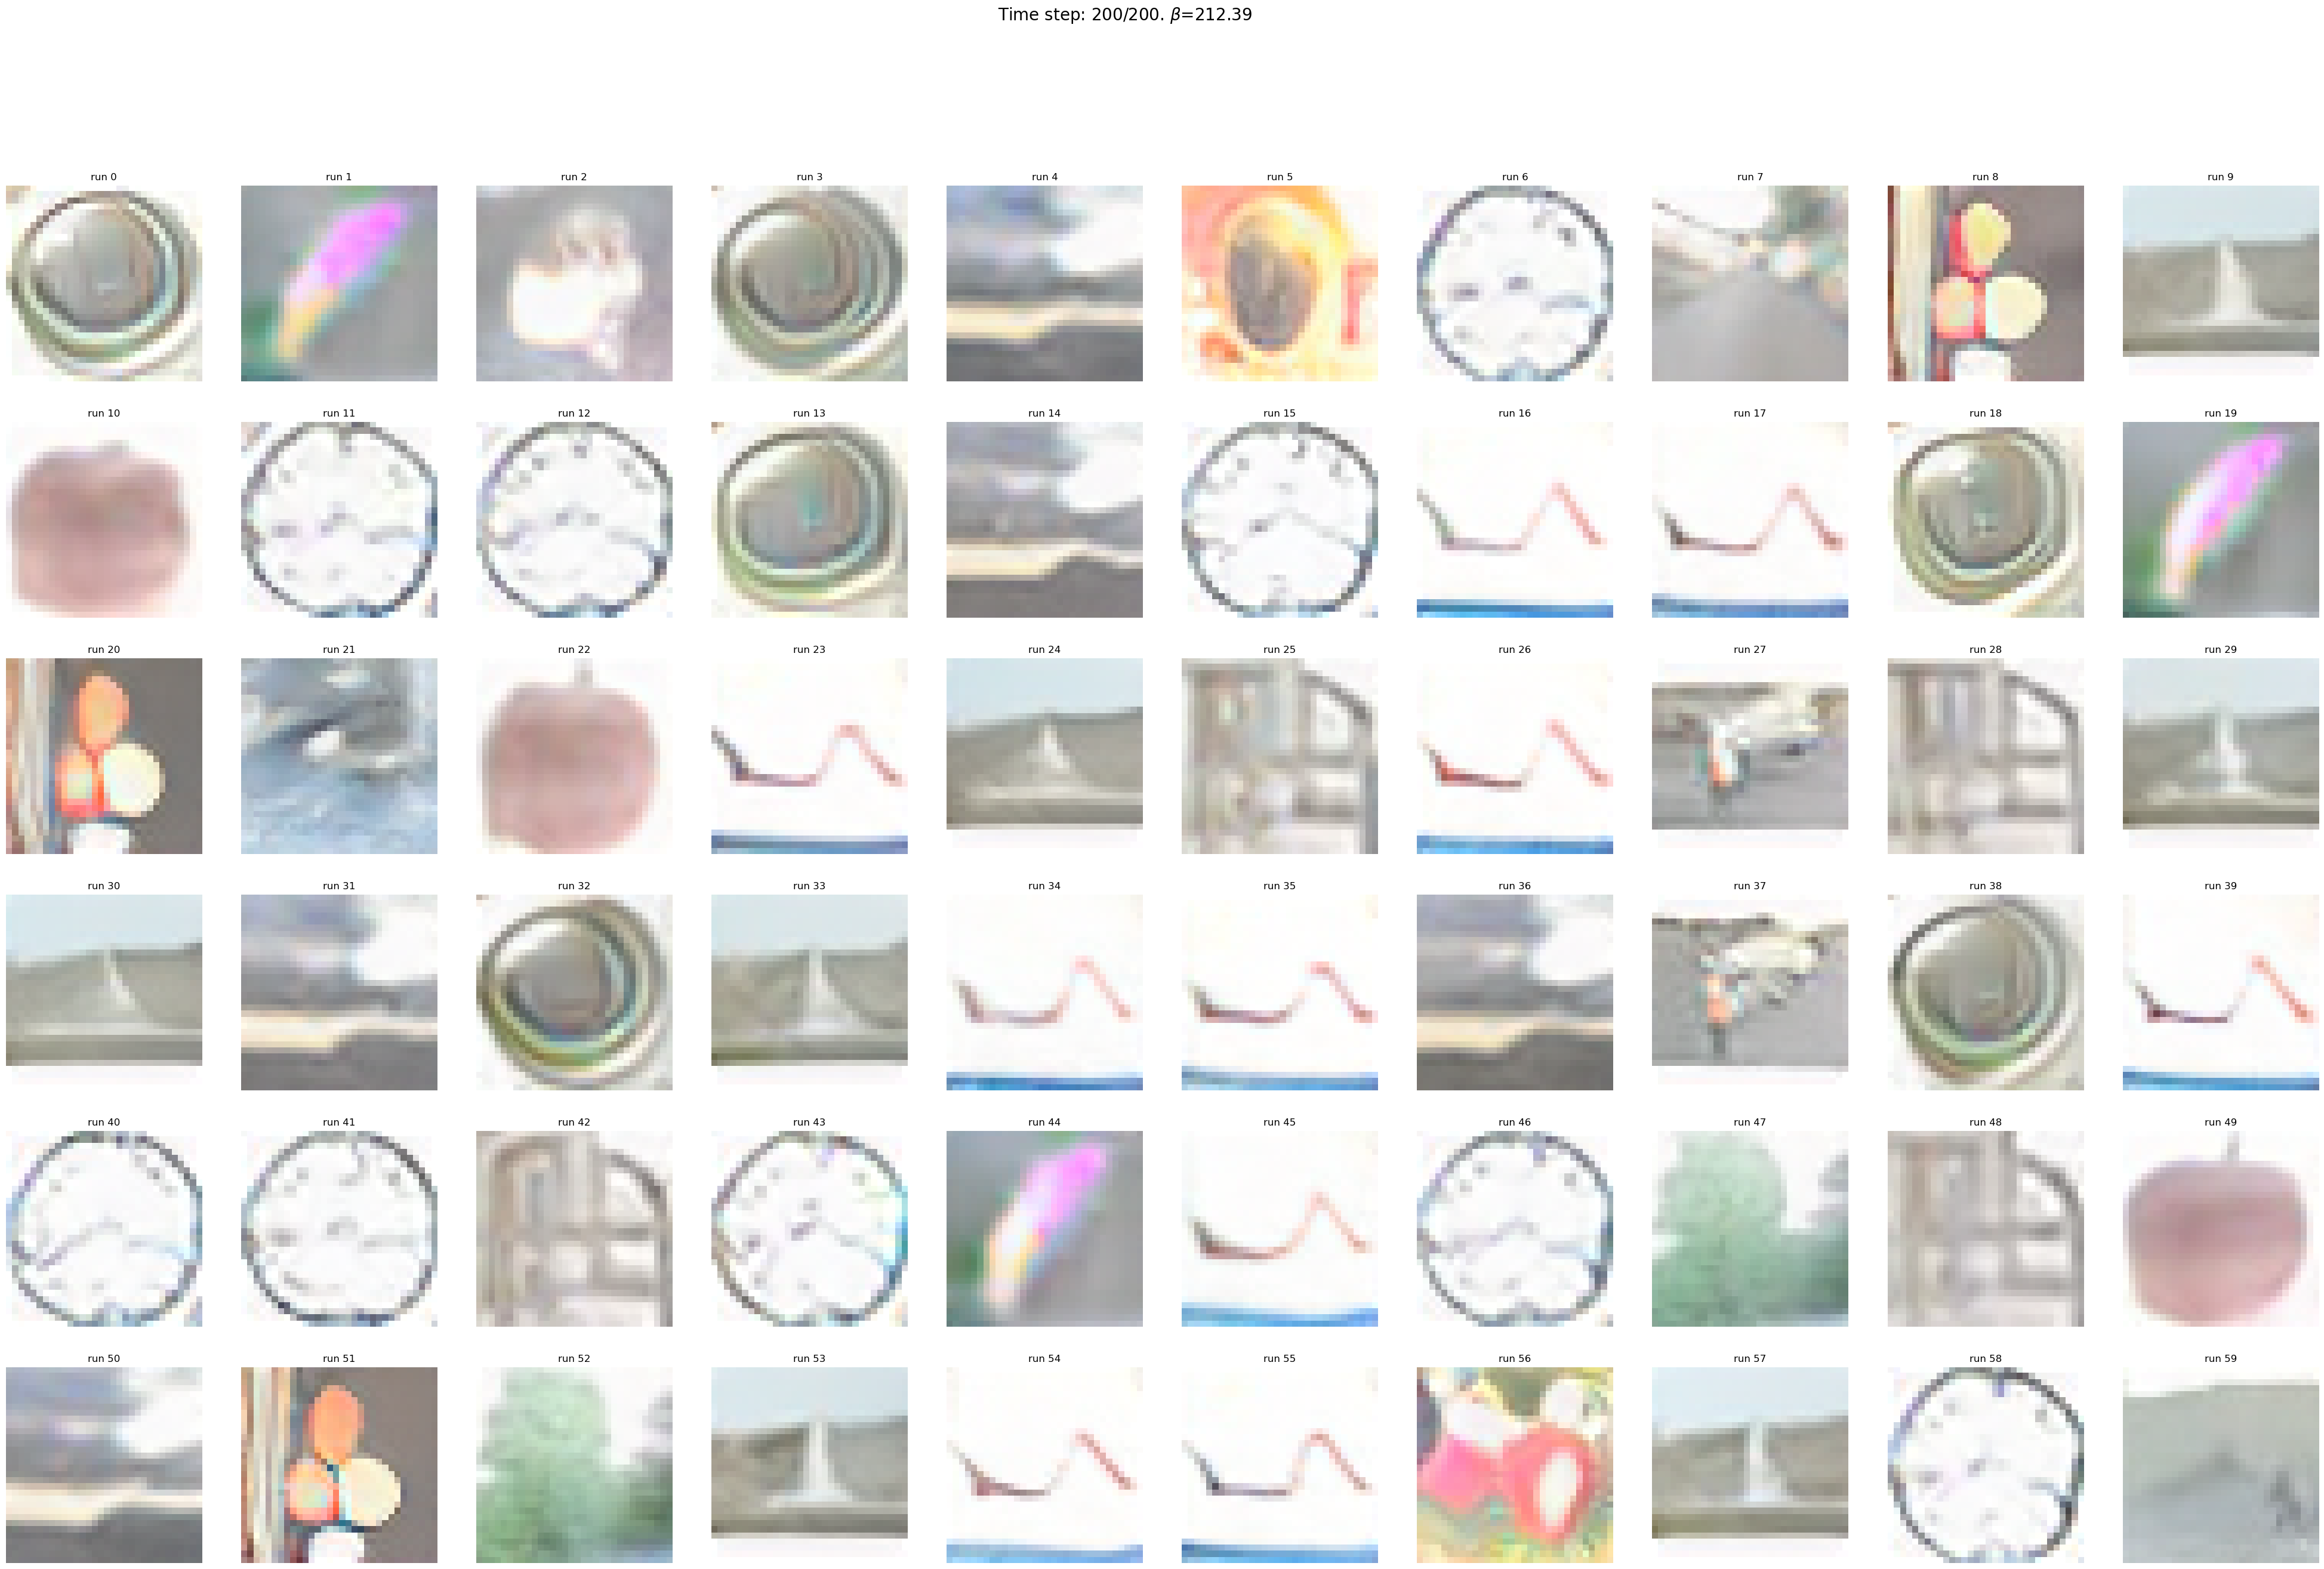

In [859]:
play_images(annealed_images, annealing_betas, "$\\beta$", num_cols=10, use_grayscale=False, base_image_size=5, pause=0.1)

#### Denoising dynamics

In [ ]:
from mhn import denoise_dynamics
torch.random.manual_seed(1101252)
TEST_BATCH_SIZE = 16
test_set_loader = DataLoader(
    test_set,
    batch_size=TEST_BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=False,
)
noise_level = 0.3
test_betas = torch.logspace(-1.5,2,50)
for batch_x, batch_y in test_set_loader:
    batch_x_noised = batch_x*(1-noise_level) + torch.rand_like(batch_x)*noise_level
    batch_x_latents = ae_model.encode(batch_x_noised.expand((-1,3,-1,-1)).to(device)).latent_dist.mode() * ae_scaling
    batch_x_reconstructed_images = ae_model.decode(batch_x_latents/ae_scaling).sample.cpu()
    batch_x_latents = batch_x_latents.cpu()
    batch_x_patterns = (batch_x_latents - mean_sampled_latents) / std_sampled_latents
    all_batch_x_denoised = []
    for beta_idx, beta in tqdm(enumerate(test_betas)):
        denoise_dynamics_input = batch_x_patterns.view(batch_x_patterns.shape[0], -1)
        batch_x_denoised = denoise_dynamics(batch_x_patterns.view(batch_x_patterns.shape[0], -1), 
                                            test_betas[beta_idx], 
                                            patterns.view(patterns.shape[0], -1),
                                            torch.zeros(patterns.shape[0]),
                                            num_steps=100,
                                            dt = 0.01,
                                            verbose=False)
        all_batch_x_denoised.append(batch_x_denoised[:,None,...])
    all_batch_x_denoised = torch.cat(all_batch_x_denoised, dim=1)
    all_batch_x_denoised = all_batch_x_denoised.view(all_batch_x_denoised.shape[0],
                                                    all_batch_x_denoised.shape[1], 
                                                    C_latents, H_latents, W_latents)
    all_batch_x_denoised_images = decode_latents(all_batch_x_denoised, mean_sampled_latents, std_sampled_latents, ae_model, ae_scaling, batch_size=64, verbose=True)
    break

In [ ]:
fig, axs = plt.subplots(ncols=all_batch_x_denoised_images.shape[0], nrows=3, figsize=(5*all_batch_x_denoised_images.shape[0],10))
ims = []
for run in range(all_batch_x_denoised_images.shape[0]):
    im = axs[0,run].imshow(all_batch_x_denoised_images[run,0,0], cmap='gray')
    ims.append(im)
    axs[1,run].imshow(batch_x_reconstructed_images[run,0], cmap='gray')
    axs[2,run].imshow(batch_x[run,0], cmap='gray')
fig.suptitle(f"Time step: {1}/{all_batch_x_denoised_images.shape[1]}. $\\beta={betas[0]:.2f}$")
display_handle = display(fig, display_id=True)
for time in range(all_batch_x_denoised_images.shape[1]):
    for run in range(all_batch_x_denoised_images.shape[0]):
        ims[run].set_data(all_batch_x_denoised_images[run,time,0])
    display_handle.update(fig)
    fig.suptitle(f"Time step: {time+1}/{all_batch_x_denoised_images.shape[1]}. $\\beta={betas[time]:.2f}$")
plt.close()

In [ ]:
num_clusters = 50
from sklearn.cluster import KMeans
clustering = KMeans(n_clusters=num_clusters, random_state=1101252).fit(latents.view(latents.shape[0],-1))

In [ ]:
clusters = torch.from_numpy(clustering.cluster_centers_).type(torch.float).view(-1, *latents.shape[1:])

In [ ]:
clusters_mean = clusters.mean(dim=0)
clusters_std = clusters.std(dim=0)
#clusters_scale = torch.sqrt(torch.sum((clusters-clusters_shift)**2, dim=(1,2,3)))

In [ ]:
patterns = (clusters - clusters_mean)/clusters_std

In [ ]:
from mhn import dynamics_gaussian_init
betas = torch.logspace(-1,2,100)
recovered_clusters, recovered_clusters_weights = dynamics_gaussian_init(betas[0], betas, patterns.view(patterns.shape[0],-1), dt=0.01, num_steps=10000, num_runs=10, verbose=True)

In [ ]:
decoded_recovered_clusters_images = decode_latents(recovered_clusters.view((recovered_clusters.shape[0], recovered_clusters.shape[1], *latents.shape[1:])),
                                                                          clusters_mean,
                                                                          clusters_std,
                                                                          ae_model,
                                                                          ae_scaling)

In [ ]:
from mhn import get_entropies
plt.plot(betas,get_entropies(recovered_clusters_weights).mean(dim=0))
plt.xscale('log')

In [ ]:
fig, axs = plt.subplots(ncols=decoded_recovered_clusters_images.shape[0], figsize=(5*decoded_recovered_clusters_images.shape[0],5))
ims = []
for run in range(decoded_recovered_clusters_images.shape[0]):
    im = axs[run].imshow(decoded_recovered_clusters_images[run,0,0], cmap='gray')
    ims.append(im)
display_handle = display(fig, display_id=True)
for time in range(decoded_recovered_clusters_images.shape[1]):
    for run in range(decoded_recovered_clusters_images.shape[0]):
        ims[run].set_data(decoded_recovered_clusters_images[run,time,0])
    display_handle.update(fig)
plt.close()

In [ ]:
decoded_recovered_images = decode_latents(recovered_patterns.view((recovered_patterns.shape[0], recovered_patterns.shape[1], *clusters.shape[1:])),
                                                                          clusters_mean,
                                                                          clusters_std,
                                                                          ae_model,
                                                                          ae_scaling)

In [ ]:
fig, axs = plt.subplots(ncols=decoded_recovered_images.shape[0], figsize=(5*decoded_recovered_images.shape[0],5))
ims = []
for run in range(decoded_recovered_images.shape[0]):
    im = axs[run].imshow(decoded_recovered_images[run,0,0], cmap='gray')
    ims.append(im)
display_handle = display(fig, display_id=True)
for time in range(decoded_recovered_images.shape[1]):
    for run in range(decoded_recovered_images.shape[0]):
        ims[run].set_data(decoded_recovered_images[run,time,0])
    display_handle.update(fig)
plt.close()

### MHN distillation

In [ ]:
import mhn
importlib.reload(mhn)
from mhn import MHN
device = 'cuda'
num_patterns = 10
latents_dataset = TensorDataset(normalized_latents)
latents_loader = DataLoader(latents_dataset, batch_size=128, shuffle=True, pin_memory=True)
distillator = MHN(input_dim=normalized_latents.shape[1], num_patterns=num_patterns).to(device)

In [ ]:
num_epochs = 100
optimizer = torch.optim.AdamW(
    distillator.parameters(),
    lr=1e-5,
    weight_decay=1e-3,
)
loss_history = []
regularization_lambda = 0.0
for epoch in range(num_epochs):
    pbar = tqdm(latents_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
    mean_loss = 0.0
    num_batches = 0
    for (z,) in pbar:   
        optimizer.zero_grad(set_to_none=True)     
        log_Z_model, log_Z_data = distillator(z.to(device), num_betas=16, teacher_student_mode=True)
        loss = (log_Z_model[:,None] - log_Z_data).mean()
        mean_loss += loss.item()
        num_batches += 1
        loss.backward()
        optimizer.step()
              
        pbar.set_postfix({
            "loss": float(loss.detach()),
            "mean_log_beta" : float(distillator.log_beta_mean.detach()),
            "std_log_beta" : float(distillator.log_beta_std.detach())        })
    distillator.center_biases()  
    mean_loss /= num_batches
    loss_history.append(mean_loss)
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {mean_loss:.4f} - mean_log_beta: {distillator.log_beta_mean.item():.4f} - std_log_beta: {distillator.log_beta_std.item():.4f}")

In [ ]:
with torch.no_grad():
    patterns = distillator.patterns.detach().cpu()
    biases = distillator.biases.detach().cpu()

In [ ]:
transformed_patterns = patterns.view(-1, *latents.shape[1:])*latents_std + latents_mean

In [ ]:
patterns_cov = torch.cov(patterns)
pc_vals, pc_vecs = torch.linalg.eigh(patterns_cov)
plt.scatter(pc_vecs[:,-1], pc_vecs[:,-2])

In [ ]:
decoded_patterns = ae_model.decode(transformed_patterns.to(device)/ae_scaling).sample.cpu()
decoded_pattern_images = (1+decoded_patterns.clamp(-1,1))/2

In [ ]:
plt.imshow(decoded_pattern_images[9].mean(dim=0))

### Pure retrival/denoising dynamics

In [ ]:
torch.random.manual_seed(1101252)
MHN_BATCH_SIZE = 1024
mhn_data_loader = DataLoader(
    dataset,
    batch_size=MHN_BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=False
)
data = []
latents = []
latents_labels = []
for (batch_x, batch_y) in tqdm(mhn_data_loader, desc="Encoding images with VAE"):
    batch_x = batch_x.to(device)
    with torch.no_grad():
        batch_x = batch_x.expand(-1, 3, -1, -1) if batch_x.shape[1] == 1 else batch_x
        z = ae_model.encode(batch_x).latent_dist.mode() * ae_scaling
    data.append(batch_x.cpu())
    latents.append(z.cpu())
    latents_labels.append(batch_y)
data = torch.cat(data, dim=0)
latents = torch.cat(latents, dim=0)
latents_labels = torch.cat(latents_labels, dim=0)

In [ ]:
num_samples_per_class = 100
balanced_data = []
balanced_latents = []
balanced_labels = []
for class_idx in range(num_classes):
    class_mask = (latents_labels == class_idx)
    class_latents = latents[class_mask]
    class_data = data[class_mask]
    if len(class_latents) >= num_samples_per_class:
        selected_indices = torch.randperm(len(class_latents))[:num_samples_per_class]
        balanced_latents.append(class_latents[selected_indices])
        balanced_data.append(class_data[selected_indices])
        balanced_labels.append(torch.full((num_samples_per_class,), class_idx, dtype=torch.long))
    else:
        balanced_latents.append(class_latents)
        balanced_data.append(class_data)
        balanced_labels.append(torch.full((len(class_latents),), class_idx, dtype=torch.long))
balanced_latents = torch.cat(balanced_latents, dim=0)
balanced_data = torch.cat(balanced_data, dim=0)
balanced_labels = torch.cat(balanced_labels, dim=0)

In [ ]:
gram_matrix = balanced_latents.view(balanced_latents.size(0), -1) @ balanced_latents.view(balanced_latents.size(0), -1).T
normalized_gram = gram_matrix / torch.sqrt(torch.diag(gram_matrix)[:, None] * torch.diag(gram_matrix)[None, :])

In [ ]:
proj = torch.eye(gram_matrix.size(0)) - torch.ones(gram_matrix.size(0))/gram_matrix.size(0)

In [ ]:
vals, vecs = torch.linalg.eigh(proj @ normalized_gram @ proj)

### MHN distillation

In [ ]:
mhn_data_loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    pin_memory=False
)
beta_c_values = []
latents = []
pbar = tqdm(mhn_data_loader)
for batch_x, batch_y in pbar:
     with torch.no_grad():
        x = batch_x.expand(-1, 3, -1, -1).to(device) * 2.0 - 1.0
        posterior = ae_model.encode(x).latent_dist
        z = posterior.mode() * ae_scaling
        latent_shape = z.shape[1:]
        z = z.reshape(z.shape[0], -1)
        batch_cov = torch.cov(z.T)
        batch_cov_r = batch_cov.mean(dim=1)
        batch_cov_c = batch_cov.mean(dim=0)
        batch_cov_m = batch_cov.mean()
        batch_cov_perp = batch_cov - batch_cov_r[:, None] - batch_cov_c[None, :] + batch_cov_m
        lambda_perp_max = torch.linalg.eigvalsh(batch_cov_perp).max()
        beta_c = batch_cov.shape[0]/lambda_perp_max
        latents.append(z.cpu())
        beta_c_values.append(beta_c.cpu())
latents = torch.cat(latents, dim=0)
beta_c_values = torch.stack(beta_c_values)

latent_dataset = TensorDataset(latents)
latent_data_loader = DataLoader(
    latent_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=0,
    pin_memory=False
)

In [ ]:
print(normaltest(beta_c_values.log()))
log_mean_beta_c = torch.log(beta_c_values).mean()
log_std_beta_c = torch.log(beta_c_values).std()

In [ ]:
import torch
import torch.nn as nn
from sklearn.cluster import KMeans

class MHN(nn.Module):
    def __init__(self, input_size, num_patterns, log_beta_mean=0.0, log_beta_std=0.0):
        super().__init__()
        self.input_size = input_size
        self.num_patterns = num_patterns

        self.patterns = nn.Parameter(
            torch.randn(num_patterns, input_size),
            requires_grad=True
        )
        self.biases = nn.Parameter(
            torch.zeros(num_patterns),
            requires_grad=True
        )

        # Better as buffers, not Parameters
        self.register_buffer("running_log_beta_mean", torch.tensor(log_beta_mean))
        self.register_buffer("running_log_beta_std", torch.tensor(log_beta_std))
        self.register_buffer("num_calls", torch.tensor(1, dtype=torch.long))
        
    

    def init_with_data(self, x):
        with torch.no_grad():
            kmeans = KMeans(n_clusters=self.num_patterns, random_state=0).fit(x.cpu().numpy())
            labels = kmeans.labels_
            label_counts = np.bincount(labels)
            label_proportions = label_counts / label_counts.sum()
            self.biases.copy_(torch.log(torch.tensor(label_proportions).float() + 1e-8))
            self.patterns.copy_(torch.from_numpy(kmeans.cluster_centers_).to(self.patterns.device))
    @torch.no_grad()
    def update_beta_stats_data(self, x, reset=False):
        if reset:
            self.running_log_beta_mean.zero_()
            self.running_log_beta_std.zero_()
            self.num_calls.zero_()

        w0 = torch.ones(x.shape[0], device=x.device)/x.shape[0]
        u = torch.sqrt(w0)
        proj = torch.eye(x.shape[0], device=x.device) - torch.outer(u, u)

        half_stab_matrix = proj @  torch.diag_embed(w0) @ x
        stability_matrix = half_stab_matrix @ half_stab_matrix.T
        vals, vecs = torch.linalg.eigh(stability_matrix)
        beta = 1.0/vals.max()
        log_beta = torch.log(beta)

        old_num_calls = self.num_calls.to(log_beta.dtype)

        old_mean = self.running_log_beta_mean
        old_std = self.running_log_beta_std

        # old population variance
        old_var = old_std.square()

        # update mean
        new_mean = (old_num_calls * old_mean + log_beta) / (old_num_calls + 1.0)

        # update second moment:
        # E[x^2] = Var[x] + E[x]^2
        old_second_moment = old_var + old_mean.square()
        new_second_moment = (
            old_num_calls * old_second_moment + log_beta.square()
        ) / (old_num_calls + 1.0)

        new_var = (new_second_moment - new_mean.square()).clamp_min(0.0)
        new_std = torch.sqrt(new_var)
        self.running_log_beta_mean.copy_(new_mean)
        self.running_log_beta_std.copy_(new_std)
        self.num_calls += 1

    

    @torch.no_grad()
    def update_beta_stats(self):
        w0 = torch.softmax(self.biases, dim=0)  # (K,)
        u = torch.sqrt(w0)
        proj = torch.eye(self.num_patterns, device=self.patterns.device) - torch.outer(u, u)

        half_stab_matrix = proj @  torch.diag_embed(w0) @ self.patterns
        stability_matrix = half_stab_matrix @ half_stab_matrix.T
        vals, vecs = torch.linalg.eigh(stability_matrix)
        beta = 1.0/vals.max()
        log_beta = torch.log(beta)

        old_num_calls = self.num_calls.to(log_beta.dtype)

        old_mean = self.running_log_beta_mean
        old_std = self.running_log_beta_std

        # old population variance
        old_var = old_std.square()

        # update mean
        new_mean = (old_num_calls * old_mean + log_beta) / (old_num_calls + 1.0)

        # update second moment:
        # E[x^2] = Var[x] + E[x]^2
        old_second_moment = old_var + old_mean.square()
        new_second_moment = (
            old_num_calls * old_second_moment + log_beta.square()
        ) / (old_num_calls + 1.0)

        new_var = (new_second_moment - new_mean.square()).clamp_min(0.0)
        new_std = torch.sqrt(new_var)
        self.running_log_beta_mean.copy_(new_mean)
        self.running_log_beta_std.copy_(new_std)
        self.num_calls += 1

    @torch.no_grad()
    def center_biases(self):
        with torch.no_grad():
            self.biases -= self.biases.mean()
    def forward(self, x, num_betas):
        """
        x: (N, D)
        returns scalar loss
        """
        N, D = x.shape

        betas = torch.exp(
            torch.randn(
                num_betas,
                device=x.device,
                dtype=x.dtype,
            ) * self.running_log_beta_std
            + self.running_log_beta_mean
        )  # (B,)

        # Q_b potentials: 1/2 ||Q_b||^2
        patterns_pot = 0.5 * torch.sum(self.patterns**2, dim=1)  # (K,)

        # P_mu . Q_b
        dot_prods = x @ self.patterns.T  # (N, K)

        # data term:
        # alpha_b + beta Q_b . x_mu
        logits_data = (
            self.biases[None, None, :]                       # (1, 1, K)
            + betas[:, None, None] * dot_prods[None, :, :]    # (B, N, K)
        )

        logZ_data = torch.logsumexp(logits_data, dim=-1)      # (B, N)

        # normalization term:
        # alpha_b + beta/2 ||Q_b||^2
        logits_norm = (
            self.biases[None, :]                              # (1, K)
            + betas[:, None] * patterns_pot[None, :]          # (B, K)
        )

        logZ_norm = torch.logsumexp(logits_norm, dim=-1)      # (B,)
        return logZ_data, logZ_norm

In [ ]:
distillator = MHN(
    input_size=latent_shape[0] * latent_shape[1] * latent_shape[2],
    num_patterns=20,
    log_beta_mean=log_mean_beta_c.item(),
    log_beta_std=log_std_beta_c.item()
).to(device)

In [ ]:
init_data_loader = DataLoader(
    latent_dataset,
    batch_size=1024,
    shuffle=True,
    num_workers=0,
    pin_memory=False
)
init_batch = next(iter(init_data_loader))[0].to(device)
distillator.init_with_data(init_batch)

In [ ]:
num_epochs = 10
optimizer = torch.optim.AdamW(
    distillator.parameters(),
    lr=1e-4,
    weight_decay=0.0,
)
loss_history = []
regularization_lambda = 1e-7
p_beta_reset = 0.1
for epoch in range(num_epochs):
    pbar = tqdm(latent_data_loader, desc=f"Epoch {epoch+1}/{num_epochs}", disable=epoch % 100 != 0)
    mean_loss = 0.0
    num_batches = 0
    for (z,) in pbar:   
        optimizer.zero_grad(set_to_none=True)     
        logZ_data, logZ_norm = distillator(z.to(device), num_betas=16)
        log_diff = logZ_norm[:, None] - logZ_data
        loss_main = log_diff.mean()
        loss_reg = regularization_lambda* (log_diff**2).mean()
        loss = loss_main + loss_reg
        mean_loss += loss.item()
        num_batches += 1
        loss.backward()
        optimizer.step()


        distillator.center_biases()

        distillator.update_beta_stats_data(z.to(device), reset=torch.rand(1).item() < p_beta_reset)
        

        pbar.set_postfix({
            "loss": float(loss.detach()),
            "mean_log_beta" : float(distillator.running_log_beta_mean.detach()),
            "std_log_beta" : float(distillator.running_log_beta_std.detach())
        })
    mean_loss /= num_batches
    loss_history.append(mean_loss)
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {mean_loss:.4f} - mean_log_beta: {distillator.running_log_beta_mean.item():.4f} - std_log_beta: {distillator.running_log_beta_std.item():.4f}")

In [ ]:
with torch.no_grad():
    scaled_patterns = distillator.patterns.view(-1, latent_shape[0], latent_shape[1], latent_shape[2]) / ae_scaling
    decoded_patterns = ae_model.decode(scaled_patterns).sample.detach().cpu().permute(0,2,3,1).clamp(-1,1)
    decoded_patterns = (decoded_patterns + 1) / 2.0

In [ ]:
for i in range(decoded_patterns.shape[0]):
    plt.imshow(decoded_patterns[i])
    plt.title(f"Bias: {distillator.biases[i].item():.2f}")
    plt.axis('off')
    plt.show()

In [ ]:
from mhn import get_entropies, dynamics_gaussian_init_with_biases
log_beta_mean = distillator.running_log_beta_mean.item()
log_beta_std = distillator.running_log_beta_std.item()
beta_denoising = torch.exp(torch.randn(10) * log_beta_std + log_beta_mean)
beta_denoising = torch.logspace(-1, 3, 50)
recovered_patterns, rp_weights = dynamics_gaussian_init_with_biases(beta_denoising[0], beta_denoising, distillator.patterns.detach().cpu(), biases=distillator.biases.detach().cpu(), dt=0.001, num_steps=10000, verbose=True, num_runs=1)

In [ ]:
entropies = get_entropies(rp_weights)

In [ ]:
plt.plot(beta_denoising, entropies.mean(dim=0))
plt.xscale('log')

In [ ]:
with torch.no_grad():
    proj_matr =torch.diag_embed(torch.softmax(distillator.biases, dim=0)) - torch.outer(torch.softmax(distillator.biases, dim=0), torch.softmax(distillator.biases, dim=0))
    gram = distillator.patterns @ distillator.patterns.T
    stability_matrix = proj_matr @ gram
    vals, vecs = torch.linalg.eigh(stability_matrix)

In [ ]:
recovered_patterns.shape

In [ ]:
recon_images = ae_model.decode(recovered_patterns.to(device).view(-1, latent_shape[0], latent_shape[1], latent_shape[2]) / ae_scaling).sample.detach().cpu().permute(0,2,3,1)
recon_images = (recon_images + 1) / 2.0
recon_images = recon_images.clamp(0,1)

In [ ]:
from skimage.color import rgb2gray

In [ ]:
for i in range(recon_images.shape[0]):
    fig, axs = plt.subplots(figsize=(4, 4))
    axs.imshow(rgb2gray(recon_images[i]), cmap='gray', vmin=-1, vmax=1)
    plt.show()

In [ ]:
random_latents = latents[torch.randperm(latents.shape[0])[:1000]].to(device)
random_images = ae_model.decode(random_latents.view(-1, latent_shape[0], latent_shape[1], latent_shape[2]) / ae_scaling).sample.detach().cpu().permute(0,2,3,1)
random_images = (random_images + 1) / 2.0
random_images = random_images.clamp(0,1)

In [ ]:
gamma = torch.tensor(0.1, device=device)
corrupted_latents = gamma * random_latents  + torch.sqrt(1 - gamma**2) * torch.randn_like(random_latents)

In [ ]:
from mhn import denoise_dynamics
denoised_patterns = denoise_dynamics(corrupted_latents.to('cpu'),
                                      distillator.running_log_beta_mean.exp().cpu()*10, 
                                      distillator.patterns.detach().cpu(),
                                    biases=distillator.biases.detach().cpu(), dt=0.001, num_steps=10000, verbose=True)

In [ ]:
denoised_images = ae_model.decode(denoised_patterns.to(device).view(-1, latent_shape[0], latent_shape[1], latent_shape[2]) / ae_scaling).sample.detach().cpu().permute(0,2,3,1)
denoised_images = (denoised_images + 1) / 2.0
denoised_images = denoised_images.clamp(0,1)

In [ ]:
with torch.no_grad():
    pattern_vals, pattern_vecs = torch.linalg.eigh(distillator.patterns.cpu() @ distillator.patterns.cpu().T/distillator.patterns.shape[1])

In [ ]:
plt.scatter(pattern_vecs[:,0], pattern_vecs[:,2])

In [ ]:
for i in range(0, denoised_images.shape[0], 50):
    fig, axs = plt.subplots(figsize=(4, 4), ncols=2)
    axs[0].imshow(random_images[i])
    axs[1].imshow(denoised_images[i])
    plt.show()

### EqM

In [ ]:
eqm_data_loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    pin_memory=False
)
beta_c_values = []
latents = []
latents_y = []
pbar = tqdm(eqm_data_loader)
for batch_x, batch_y in pbar:
     with torch.no_grad():
        x = batch_x.expand(-1, 3, -1, -1).to(device) * 2.0 - 1.0
        posterior = ae_model.encode(x).latent_dist
        z = posterior.mode() * ae_scaling
        batch_cov = torch.cov(z.view(z.shape[0], -1).T)
        batch_cov_r = batch_cov.mean(dim=1)
        batch_cov_c = batch_cov.mean(dim=0)
        batch_cov_m = batch_cov.mean()
        batch_cov_perp = batch_cov - batch_cov_r[:, None] - batch_cov_c[None, :] + batch_cov_m
        lambda_perp_max = torch.linalg.eigvalsh(batch_cov_perp).max()
        beta_c = batch_cov.shape[0]/lambda_perp_max
        latents.append(z.cpu())
        beta_c_values.append(beta_c.cpu())
        latents_y.append(batch_y)
latents = torch.cat(latents, dim=0)
beta_c_values = torch.stack(beta_c_values)
latents_y = torch.cat(latents_y)

latent_dataset = TensorDataset(latents, latents_y)
latent_data_loader = DataLoader(
    latent_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=0,
    pin_memory=False
)

In [ ]:
from eqm.models import EqM_models
model = EqM_models['EqM-S/1'](num_classes=num_classes, input_size=latents.shape[-1], in_channels=4, learn_sigma=True, ebm='l2').to(device)

In [ ]:
torch.backends.cuda.enable_flash_sdp(False)
torch.backends.cuda.enable_mem_efficient_sdp(False)
torch.backends.cuda.enable_math_sdp(True)

for m in model.modules():
    if hasattr(m, "fused_attn"):
        m.fused_attn = False

In [ ]:
model = model.train()

In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-7)

In [ ]:
num_epochs = 10
for epoch in range(num_epochs):
    pbar = tqdm(latent_data_loader, desc=f"Epoch {epoch+1}/{num_epochs}", disable=epoch % 100 != 0)
    mean_loss = 0.0
    num_batches = 0
    for (x, y) in pbar:   
        optimizer.zero_grad(set_to_none=True)     
        x = x.to(device)
        y = y.to(device)
        model_output = model(x, y, get_energy=False, train=True)
        loss = (model_output - x).pow(2).sum(dim=1).mean()
        loss.backward()
        
        num_batches += 1
        loss.backward()
        optimizer.step()

        mean_loss += loss.item()

        pbar.set_postfix({
            "loss": float(loss.item()),
        })
    mean_loss /= num_batches
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {mean_loss:.4f}")